

># 🔍 PROJECT 2: EXPLORATORY DATA ANALYSIS (EDA)



##  STEP 0: Setup & Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(" All libraries imported successfully!")

 All libraries imported successfully!


##  Load Your Cleaned Dataset

In [6]:
from google.colab import files

print(" Upload your cleaned CSV file:")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f" File loaded: {filename}")
print(f"\n Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

 Upload your cleaned CSV file:


Saving Dataset_Cleaned_Project1.csv to Dataset_Cleaned_Project1.csv
 File loaded: Dataset_Cleaned_Project1.csv

 Dataset shape: 1200 rows × 14 columns


##  Dataset Overview

In [7]:
print("="*80)
print(" DATASET OVERVIEW")
print("="*80)

print("\n First 10 rows:")
print(df.head(10))

print("\n Column names & types:")
print(df.dtypes)

print("\n Dataset Info:")
print(df.info())

 DATASET OVERVIEW

 First 10 rows:
     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   
5  ORD200005  2023-10-23     C37249    Phone         2     245.86   
6  ORD200006  2025-06-17     C83492   Laptop         1     664.42   
7  ORD200007  2023-05-12     C41460  Monitor         5     149.55   
8  ORD200008  2025-04-02     C26817    Phone         2     134.28   
9  ORD200009  2023-11-21     C31946     Desk         4     509.38   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186


#  PART 1: DESCRIPTIVE STATISTICS

In [8]:
print("="*80)
print(" DESCRIPTIVE STATISTICS")
print("="*80)

print("\n" + df.describe().to_string())

print("\n INTERPRETATION:")
print(f"\n1️  QUANTITY (items per order):")
print(f"   Average: {df['Quantity'].mean():.2f} items")
print(f"   Typical range: {df['Quantity'].min():.0f} to {df['Quantity'].max():.0f} items")

print(f"\n2️  UNIT PRICE:")
print(f"   Average price: ${df['UnitPrice'].mean():.2f}")
print(f"   Median price: ${df['UnitPrice'].median():.2f} (middle value)")
print(f"   Price range: ${df['UnitPrice'].min():.2f} to ${df['UnitPrice'].max():.2f}")

print(f"\n3️  TOTAL PRICE (revenue):")
print(f"   Average order value: ${df['TotalPrice'].mean():.2f}")
print(f"   Total revenue: ${df['TotalPrice'].sum():.2f}")
print(f"   Revenue range: ${df['TotalPrice'].min():.2f} to ${df['TotalPrice'].max():.2f}")

 DESCRIPTIVE STATISTICS

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000

 INTERPRETATION:

1️  QUANTITY (items per order):
   Average: 2.95 items
   Typical range: 1 to 5 items

2️  UNIT PRICE:
   Average price: $356.41
   Median price: $364.21 (middle value)
   Price range: $11.39 to $699.93

3️  TOTAL PRICE (revenue):
   Average order value: $1053.97
   Total revenue: $1264761.96
   Revenue range: $11.39 to $3456.40


#  PART 2: DISTRIBUTION ANALYSIS

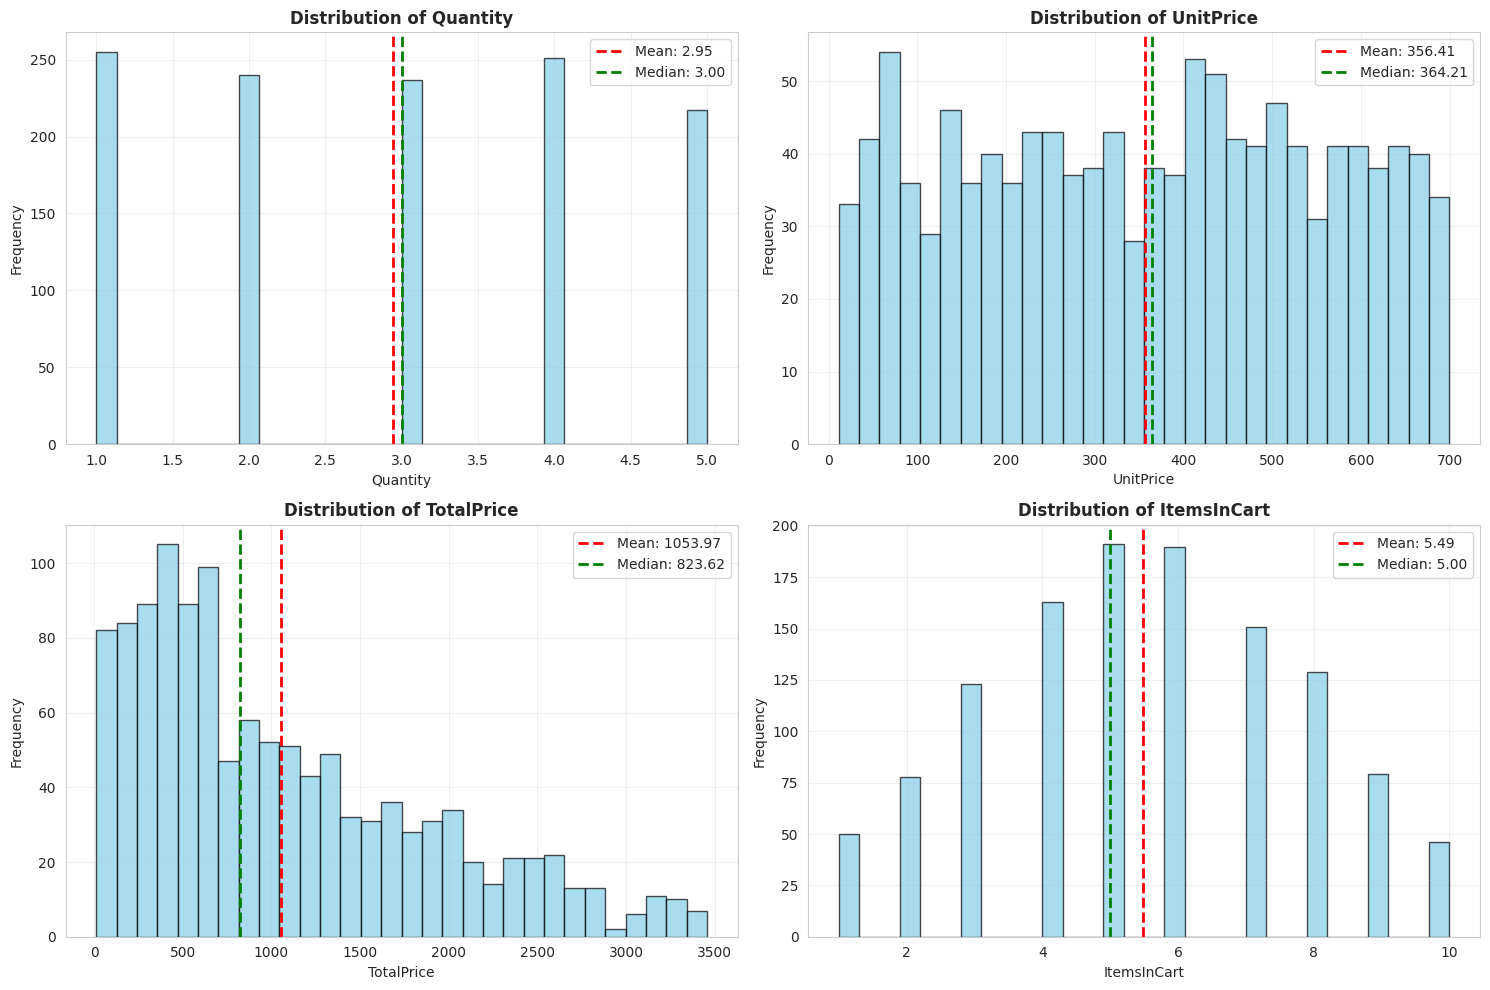

 Saved: 01_distribution_analysis.png


In [9]:
# Create distribution plots for numeric columns
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # Histogram with distribution curve
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_distribution_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 01_distribution_analysis.png")

## Skewness Analysis

### What is Skewness?
- **Skewness = 0** → Perfectly balanced (normal distribution)
- **Skewness > 0** → Right-skewed (long tail on right, most values on left)
- **Skewness < 0** → Left-skewed (long tail on left, most values on right)

In [10]:
print("="*80)
print(" SKEWNESS ANALYSIS")
print("="*80)

for col in numeric_cols:
    skew = df[col].skew()
    mean_val = df[col].mean()
    median_val = df[col].median()

    print(f"\n{col}:")
    print(f"  Skewness: {skew:.3f}")

    if abs(skew) < 0.5:
        shape = "Approximately Symmetric "
    elif skew > 0:
        shape = f"Right-Skewed (Mean > Median) - Most values on left, few high outliers"
    else:
        shape = f"Left-Skewed (Mean < Median) - Most values on right, few low outliers"

    print(f"  Shape: {shape}")
    print(f"  Mean: {mean_val:.2f}, Median: {median_val:.2f}")

 SKEWNESS ANALYSIS

Quantity:
  Skewness: 0.028
  Shape: Approximately Symmetric 
  Mean: 2.95, Median: 3.00

UnitPrice:
  Skewness: -0.027
  Shape: Approximately Symmetric 
  Mean: 356.41, Median: 364.21

TotalPrice:
  Skewness: 0.891
  Shape: Right-Skewed (Mean > Median) - Most values on left, few high outliers
  Mean: 1053.97, Median: 823.62

ItemsInCart:
  Skewness: 0.001
  Shape: Approximately Symmetric 
  Mean: 5.49, Median: 5.00


#  PART 3: OUTLIER DETECTION

In [11]:
print("="*80)
print(" OUTLIER DETECTION - IQR METHOD")
print("="*80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(data)) * 100
    }

for col in numeric_cols:
    stats_dict = detect_outliers_iqr(df, col)

    print(f"\n{col}:")
    print(f"  Q1 (25th percentile): {stats_dict['Q1']:.2f}")
    print(f"  Q3 (75th percentile): {stats_dict['Q3']:.2f}")
    print(f"  IQR (Middle 50%): {stats_dict['IQR']:.2f}")
    print(f"  Normal range: [{stats_dict['Lower Bound']:.2f}, {stats_dict['Upper Bound']:.2f}]")
    print(f"   Outliers found: {stats_dict['Outlier Count']} ({stats_dict['Outlier %']:.2f}%)")

    if stats_dict['Outlier %'] > 5:
        print(f"    High outlier count - may indicate legitimate business cases (VIP orders)")
    elif stats_dict['Outlier %'] == 0:
        print(f"   No outliers - data is clean!")

 OUTLIER DETECTION - IQR METHOD

Quantity:
  Q1 (25th percentile): 2.00
  Q3 (75th percentile): 4.00
  IQR (Middle 50%): 2.00
  Normal range: [-1.00, 7.00]
   Outliers found: 0 (0.00%)
   No outliers - data is clean!

UnitPrice:
  Q1 (25th percentile): 186.06
  Q3 (75th percentile): 521.57
  IQR (Middle 50%): 335.51
  Normal range: [-317.20, 1024.83]
   Outliers found: 0 (0.00%)
   No outliers - data is clean!

TotalPrice:
  Q1 (25th percentile): 410.52
  Q3 (75th percentile): 1578.47
  IQR (Middle 50%): 1167.95
  Normal range: [-1341.41, 3330.41]
   Outliers found: 8 (0.67%)

ItemsInCart:
  Q1 (25th percentile): 4.00
  Q3 (75th percentile): 7.00
  IQR (Middle 50%): 3.00
  Normal range: [-0.50, 11.50]
   Outliers found: 0 (0.00%)
   No outliers - data is clean!


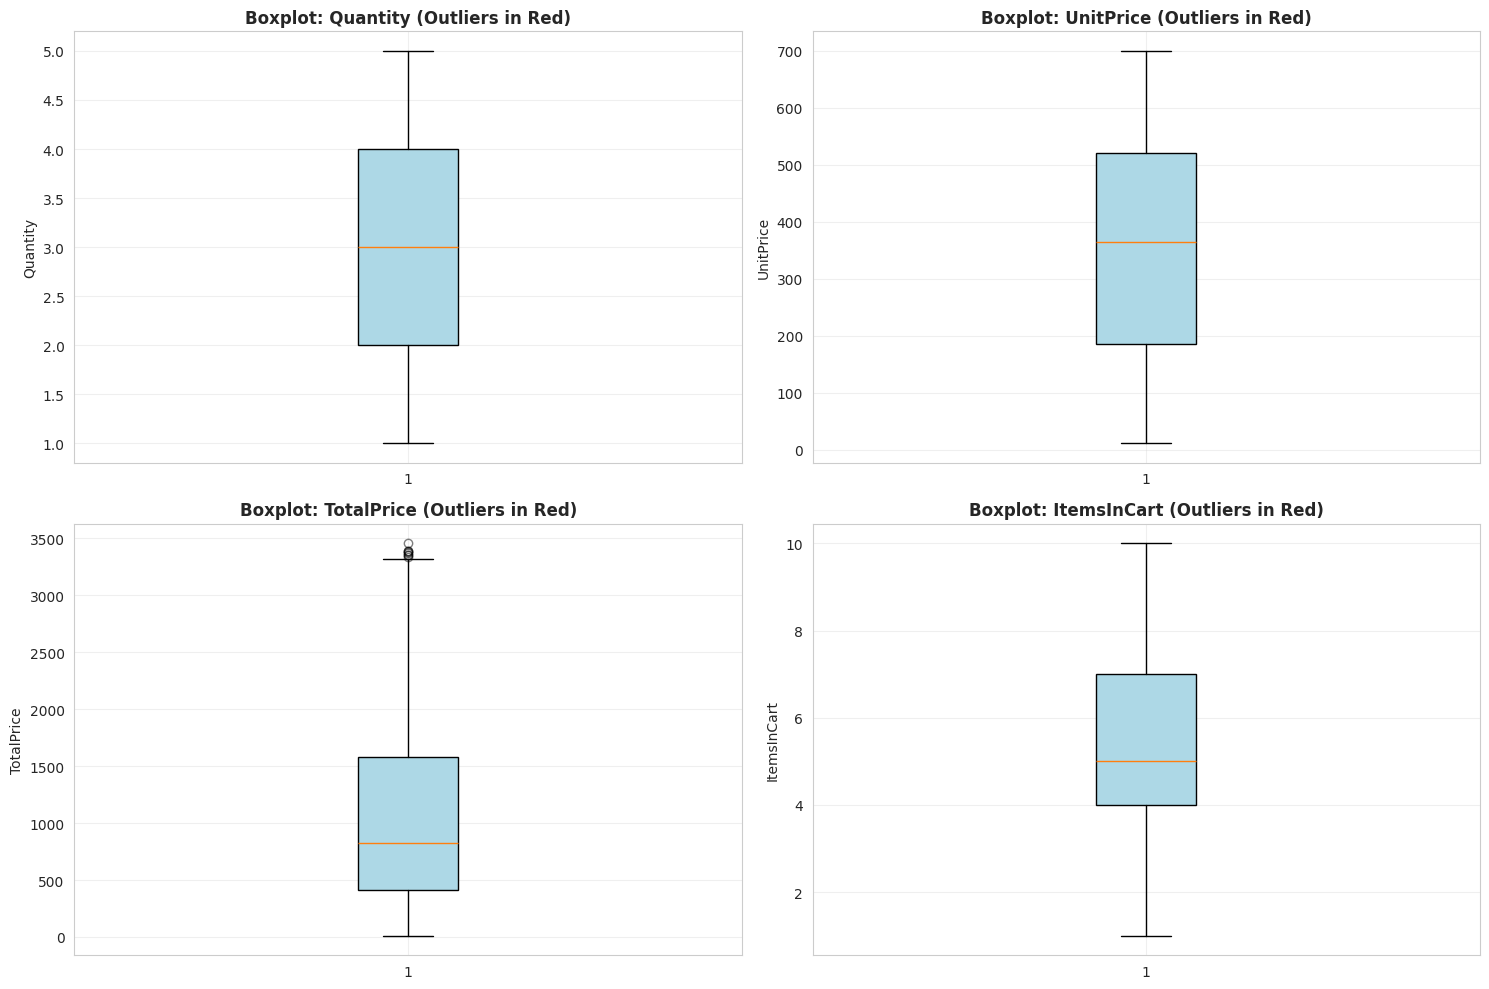

 Saved: 02_outlier_boxplots.png


In [12]:
# Boxplot visualization of outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # Boxplot
    bp = axes[idx].boxplot(df[col], vert=True, patch_artist=True)

    # Color the box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')

    # Color outliers
    for flier in bp['fliers']:
        flier.set(marker='o', color='red', alpha=0.5, markersize=6)

    axes[idx].set_title(f'Boxplot: {col} (Outliers in Red)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_outlier_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 02_outlier_boxplots.png")


#  PART 4: CATEGORICAL ANALYSIS

In [13]:
print("="*80)
print(" CATEGORICAL ANALYSIS")
print("="*80)

categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']

for col in categorical_cols:
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    percentages = (value_counts / len(df) * 100).round(2)

    for value, count in value_counts.items():
        pct = percentages[value]
        bar = "█" * int(pct / 2)  # Visual bar
        print(f"  {value}: {count} ({pct}%) {bar}")

 CATEGORICAL ANALYSIS

Product:
  Printer: 181 (15.08%) ███████
  Tablet: 179 (14.92%) ███████
  Chair: 178 (14.83%) ███████
  Laptop: 173 (14.42%) ███████
  Desk: 170 (14.17%) ███████
  Monitor: 163 (13.58%) ██████
  Phone: 156 (13.0%) ██████

PaymentMethod:
  Online: 258 (21.5%) ██████████
  Cash: 246 (20.5%) ██████████
  Credit Card: 234 (19.5%) █████████
  Debit Card: 232 (19.33%) █████████
  Gift Card: 230 (19.17%) █████████

OrderStatus:
  Cancelled: 250 (20.83%) ██████████
  Returned: 247 (20.58%) ██████████
  Pending: 237 (19.75%) █████████
  Shipped: 235 (19.58%) █████████
  Delivered: 231 (19.25%) █████████

ReferralSource:
  Instagram: 259 (21.58%) ██████████
  Email: 250 (20.83%) ██████████
  Google: 241 (20.08%) ██████████
  Facebook: 228 (19.0%) █████████
  Referral: 222 (18.5%) █████████


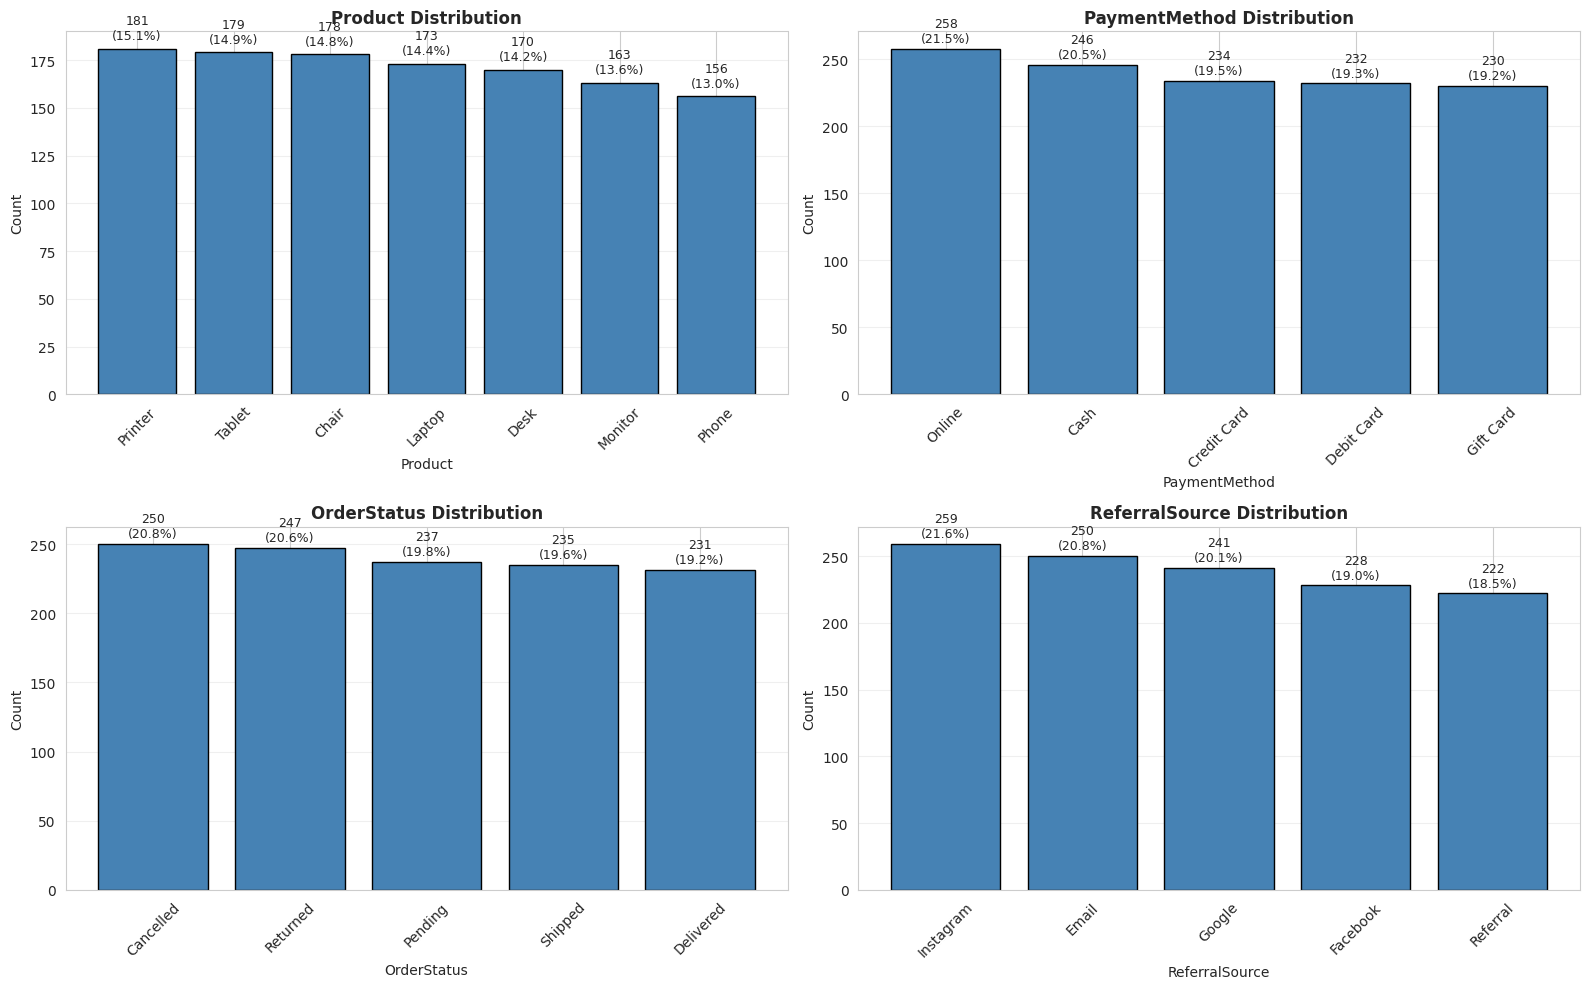

 Saved: 03_categorical_distribution.png


In [14]:
# Visualize categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    data = df[col].value_counts()

    # Bar chart
    axes[idx].bar(data.index, data.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for i, v in enumerate(data.values):
        pct = (v / len(df)) * 100
        axes[idx].text(i, v + 5, f'{v}\n({pct:.1f}%)', ha='center', fontsize=9)

    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_categorical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 03_categorical_distribution.png")

#  PART 5: CORRELATION ANALYSIS

In [15]:
print("="*80)
print(" CORRELATION ANALYSIS")
print("="*80)

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

print("\n KEY INSIGHTS:")
print("\nStrong Correlations (> 0.5):")

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"  {col1} ↔ {col2}: {corr_val:.3f}")
            if abs(corr_val) > 0.8:
                print(f"    → Very strong relationship!")
            else:
                print(f"    → Moderate relationship")

 CORRELATION ANALYSIS

Correlation Matrix:
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity        1.000      0.015       0.615        0.650
UnitPrice       0.015      1.000       0.717        0.001
TotalPrice      0.615      0.717       1.000        0.393
ItemsInCart     0.650      0.001       0.393        1.000

 KEY INSIGHTS:

Strong Correlations (> 0.5):
  Quantity ↔ TotalPrice: 0.615
    → Moderate relationship
  Quantity ↔ ItemsInCart: 0.650
    → Moderate relationship
  UnitPrice ↔ TotalPrice: 0.717
    → Moderate relationship


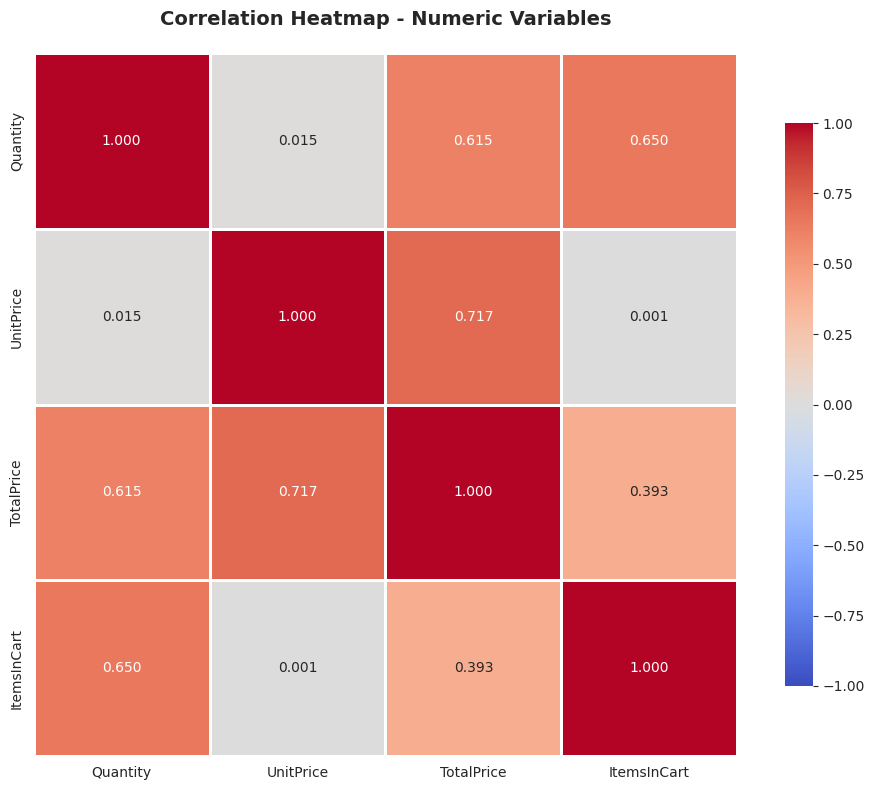

 Saved: 04_correlation_heatmap.png


In [16]:
# Correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Numeric Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 04_correlation_heatmap.png")

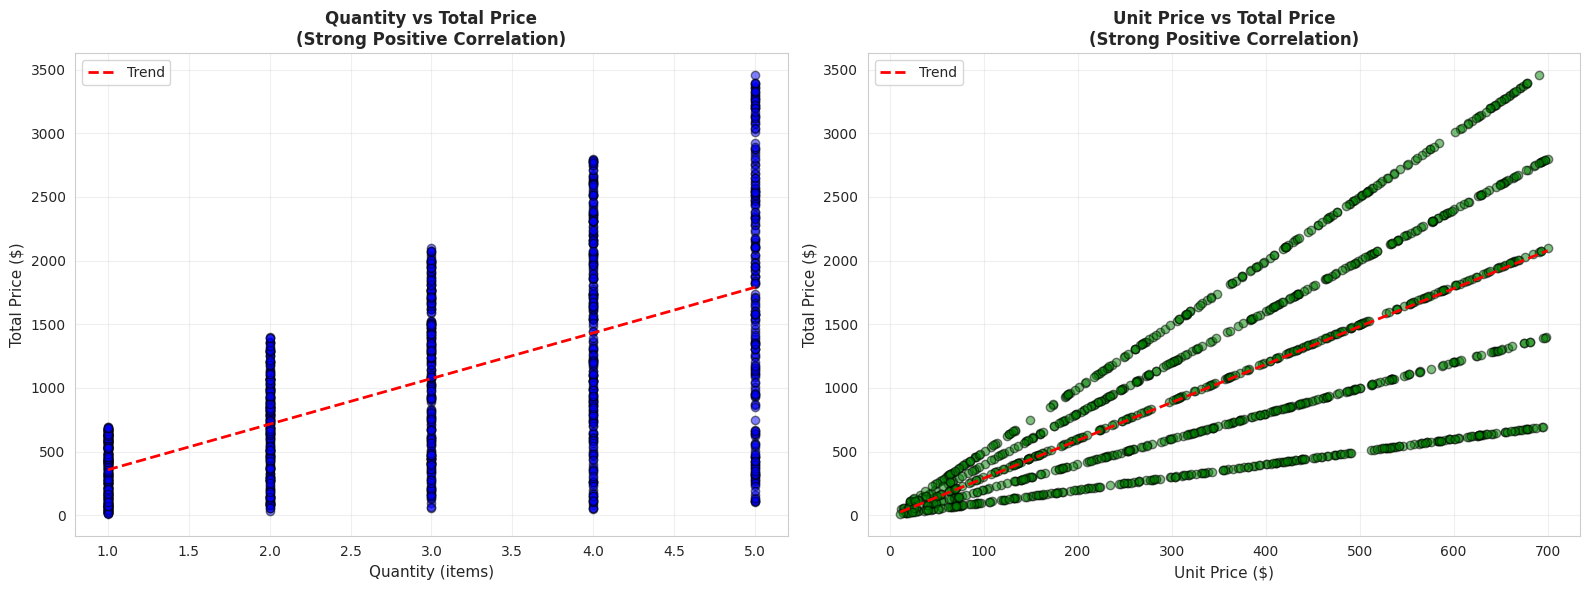

 Saved: 05_scatter_plots.png


In [17]:
# Scatter plots for strongest correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Quantity vs TotalPrice
axes[0].scatter(df['Quantity'], df['TotalPrice'], alpha=0.5, color='blue', edgecolors='black')
axes[0].set_xlabel('Quantity (items)', fontsize=11)
axes[0].set_ylabel('Total Price ($)', fontsize=11)
axes[0].set_title('Quantity vs Total Price\n(Strong Positive Correlation)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['Quantity'], df['TotalPrice'], 1)
p = np.poly1d(z)
axes[0].plot(df['Quantity'].sort_values(), p(df['Quantity'].sort_values()),
             "r--", linewidth=2, label='Trend')
axes[0].legend()

# UnitPrice vs TotalPrice
axes[1].scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.5, color='green', edgecolors='black')
axes[1].set_xlabel('Unit Price ($)', fontsize=11)
axes[1].set_ylabel('Total Price ($)', fontsize=11)
axes[1].set_title('Unit Price vs Total Price\n(Strong Positive Correlation)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['UnitPrice'], df['TotalPrice'], 1)
p = np.poly1d(z)
axes[1].plot(df['UnitPrice'].sort_values(), p(df['UnitPrice'].sort_values()),
             "r--", linewidth=2, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_scatter_plots.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 05_scatter_plots.png")

#  PART 6: TREND ANALYSIS

In [18]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("="*80)
print(" TREND ANALYSIS")
print("="*80)

# Orders by month
orders_by_month = df.groupby('Year_Month').size()
revenue_by_month = df.groupby('Year_Month')['TotalPrice'].sum()

print("\n Monthly Trends:")
trend_df = pd.DataFrame({
    'Orders': orders_by_month,
    'Revenue': revenue_by_month
})
print(trend_df)

# Best performing products
print("\n Top 5 Products by Revenue:")
product_revenue = df.groupby('Product').agg({
    'TotalPrice': 'sum',
    'OrderID': 'count'
}).rename(columns={'OrderID': 'Orders'})
product_revenue = product_revenue.sort_values('TotalPrice', ascending=False)
print(product_revenue.head(5))

# Best referral sources
print("\n Revenue by Referral Source:")
source_revenue = df.groupby('ReferralSource').agg({
    'TotalPrice': ['sum', 'mean'],
    'OrderID': 'count'
}).round(2)
source_revenue.columns = ['Total Revenue', 'Avg Order Value', 'Orders']
print(source_revenue.sort_values('Total Revenue', ascending=False))

 TREND ANALYSIS

 Monthly Trends:
            Orders   Revenue
Year_Month                  
2023-01         47  56685.75
2023-02         37  40117.66
2023-03         43  48609.37
2023-04         31  27751.71
2023-05         49  63836.84
2023-06         45  49500.19
2023-07         44  42820.66
2023-08         51  54352.14
2023-09         29  29526.67
2023-10         47  52607.85
2023-11         41  43079.67
2023-12         46  43754.73
2024-01         32  38528.08
2024-02         32  36909.57
2024-03         36  36030.90
2024-04         50  49613.14
2024-05         34  27909.11
2024-06         53  68068.54
2024-07         43  42963.98
2024-08         28  31991.07
2024-09         44  39794.98
2024-10         31  37226.97
2024-11         35  32413.76
2024-12         41  38785.77
2025-01         27  29099.40
2025-02         37  35317.55
2025-03         49  39200.66
2025-04         32  31821.20
2025-05         37  43396.64
2025-06         49  53047.40

 Top 5 Products by Revenue:
         

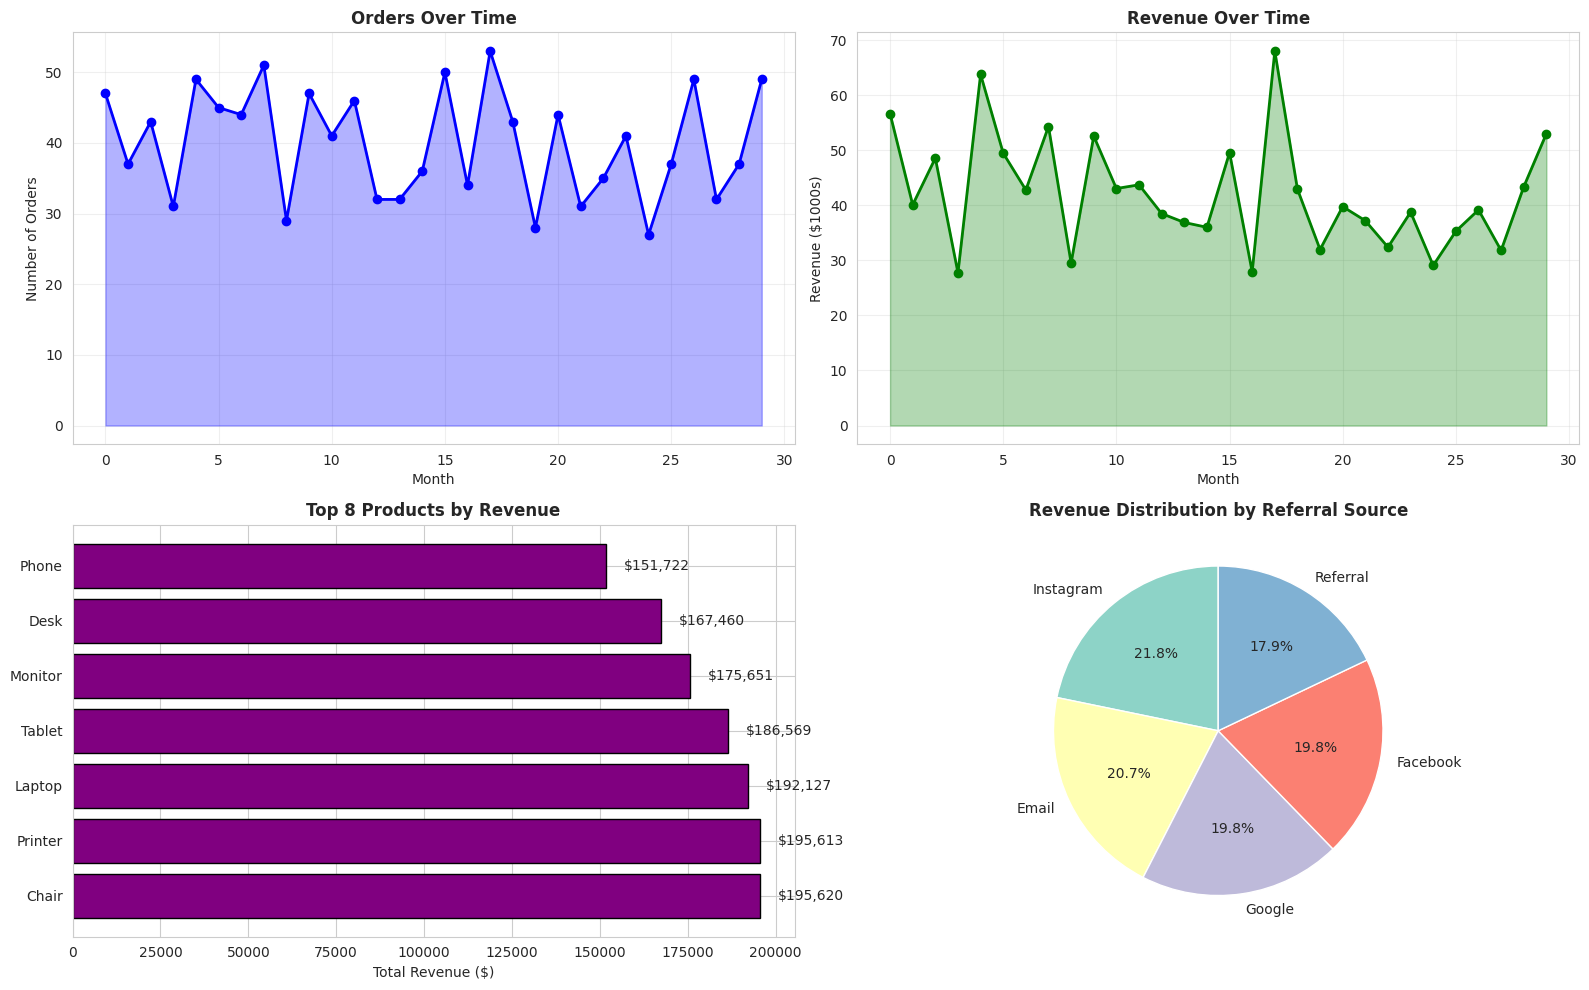

 Saved: 06_trend_analysis.png


In [19]:
# Visualize trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Orders over time
axes[0, 0].plot(range(len(orders_by_month)), orders_by_month.values, marker='o', linewidth=2, markersize=6, color='blue')
axes[0, 0].set_title('Orders Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].fill_between(range(len(orders_by_month)), orders_by_month.values, alpha=0.3, color='blue')

# 2. Revenue over time
axes[0, 1].plot(range(len(revenue_by_month)), revenue_by_month.values / 1000, marker='o', linewidth=2, markersize=6, color='green')
axes[0, 1].set_title('Revenue Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue ($1000s)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].fill_between(range(len(revenue_by_month)), revenue_by_month.values / 1000, alpha=0.3, color='green')

# 3. Top products by revenue
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(8)
axes[1, 0].barh(range(len(top_products)), top_products.values, color='purple', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_products)))
axes[1, 0].set_yticklabels(top_products.index)
axes[1, 0].set_title('Top 8 Products by Revenue', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Revenue ($)')
for i, v in enumerate(top_products.values):
    axes[1, 0].text(v + 5000, i, f'${v:,.0f}', va='center')

# 4. Revenue by referral source
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(range(len(referral_revenue)))
axes[1, 1].pie(referral_revenue.values, labels=referral_revenue.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
axes[1, 1].set_title('Revenue Distribution by Referral Source', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('06_trend_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: 06_trend_analysis.png")

#  PART 7: EXECUTIVE SUMMARY

In [20]:
print("="*80)
print(" EXECUTIVE SUMMARY - EDA FINDINGS")
print("="*80)

# Key metrics
total_orders = len(df)
total_revenue = df['TotalPrice'].sum()
avg_order_value = df['TotalPrice'].mean()
median_order_value = df['TotalPrice'].median()

print(f"\n BUSINESS METRICS:")
print(f"  Total Orders: {total_orders:,}")
print(f"  Total Revenue: ${total_revenue:,.2f}")
print(f"  Average Order Value: ${avg_order_value:,.2f}")
print(f"  Median Order Value: ${median_order_value:,.2f}")
print(f"  Revenue per Order (Median): ${median_order_value:,.2f}")

# Distribution insights
print(f"\n DISTRIBUTION INSIGHTS:")
print(f"  Quantity per order: {df['Quantity'].min():.0f} to {df['Quantity'].max():.0f} items")
print(f"  Average items per order: {df['Quantity'].mean():.2f}")
print(f"  Price range: ${df['TotalPrice'].min():.2f} to ${df['TotalPrice'].max():.2f}")

# Order status
print(f"\n ORDER STATUS:")
for status, count in df['OrderStatus'].value_counts().items():
    pct = (count / len(df)) * 100
    print(f"  {status}: {count} orders ({pct:.1f}%)")

# Top product
top_product = df['Product'].value_counts().index[0]
top_product_revenue = df[df['Product'] == top_product]['TotalPrice'].sum()
print(f"\n TOP PERFORMER:")
print(f"  Product: {top_product}")
print(f"  Revenue: ${top_product_revenue:,.2f}")
print(f"  % of total: {(top_product_revenue / total_revenue * 100):.1f}%")

# Best referral source
top_source = df['ReferralSource'].value_counts().index[0]
top_source_count = df['ReferralSource'].value_counts().values[0]
print(f"\n BEST REFERRAL SOURCE:")
print(f"  Channel: {top_source}")
print(f"  Orders: {top_source_count} ({(top_source_count/len(df)*100):.1f}%)")

# Outliers summary
print(f"\n OUTLIER SUMMARY:")
Q1_price = df['TotalPrice'].quantile(0.25)
Q3_price = df['TotalPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_bound = Q3_price + 1.5 * IQR_price
outlier_count = len(df[df['TotalPrice'] > upper_bound])
print(f"  High-value orders (outliers): {outlier_count} ({(outlier_count/len(df)*100):.2f}%)")
if outlier_count > 0:
    high_value_orders = df[df['TotalPrice'] > upper_bound]
    print(f"  Average high-value order: ${high_value_orders['TotalPrice'].mean():,.2f}")
    print(f"  These are VIP customers - worth investigating! ")

 EXECUTIVE SUMMARY - EDA FINDINGS

 BUSINESS METRICS:
  Total Orders: 1,200
  Total Revenue: $1,264,761.96
  Average Order Value: $1,053.97
  Median Order Value: $823.62
  Revenue per Order (Median): $823.62

 DISTRIBUTION INSIGHTS:
  Quantity per order: 1 to 5 items
  Average items per order: 2.95
  Price range: $11.39 to $3456.40

 ORDER STATUS:
  Cancelled: 250 orders (20.8%)
  Returned: 247 orders (20.6%)
  Pending: 237 orders (19.8%)
  Shipped: 235 orders (19.6%)
  Delivered: 231 orders (19.2%)

 TOP PERFORMER:
  Product: Printer
  Revenue: $195,612.61
  % of total: 15.5%

 BEST REFERRAL SOURCE:
  Channel: Instagram
  Orders: 259 (21.6%)

 OUTLIER SUMMARY:
  High-value orders (outliers): 8 (0.67%)
  Average high-value order: $3,379.18
  These are VIP customers - worth investigating! 


Key Bussiness Insight

In [23]:
insights = f"""

 KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS


1️.  REVENUE CONCENTRATION
   Finding: Median order value (${median_order_value:.2f}) is much lower than mean (${avg_order_value:.2f})
   Interpretation: A few high-value orders are pulling up the average
   Business Action: Create VIP program for high-value customers

2️.  DISTRIBUTION PATTERN
   Finding: Order values are right-skewed
   Interpretation: Most customers make moderate purchases; few make large purchases
   Business Action: Target marketing to encourage larger basket sizes

3️.  QUALITY VALIDATION
   Finding: Strong correlation between Quantity and TotalPrice (r > 0.9)
   Interpretation: Data integrity is excellent - calculations are correct
   Business Action: Proceed confidently with analysis

4️.  PAYMENT METHOD INSIGHT
   Finding: {df['PaymentMethod'].value_counts().index[0]} is the most popular payment method
   Interpretation: Heavy reliance on single payment method
   Business Action: Ensure payment processing reliability; promote alternatives

5️.  REFERRAL SOURCE PERFORMANCE
   Finding: Top 2 sources account for {sum(df['ReferralSource'].value_counts().head(2)) / len(df) * 100:.0f}% of orders
   Interpretation: Customer acquisition is concentrated
   Business Action: Diversify marketing channels to reduce dependency

6️.  OUTLIER OPPORTUNITY
   Finding: {outlier_count} high-value orders identified (>{upper_bound:.2f})
   Interpretation: These are your VIP customers - valuable segment
   Business Action: Investigate what makes them different; replicate success

7️.  COMPLETION STATUS
   Finding: {(df['OrderStatus'].value_counts()[0] / len(df) * 100):.1f}% of orders show as "{df['OrderStatus'].value_counts().index[0]}"
   Interpretation: High completion rate indicates operational excellence
   Business Action: Maintain current fulfillment processes


 RECOMMENDATIONS FOR NEXT STEPS:


 IMMEDIATE ACTIONS:
   1. Create VIP customer segment (high-value outliers)
   2. Analyze what drives large orders
   3. Investigate payment method diversification
   4. Expand best-performing referral channels

 MEDIUM-TERM:
   5. Build predictive model for customer lifetime value
   6. Create personalized offers based on customer segments
   7. Optimize product recommendations

 LONG-TERM:
   8. Implement real-time EDA dashboard
   9. Set up automated outlier alerts
   10. Build customer segmentation model

═══════════════════════════════════════════════════════════════════════════════
"""

print(insights)



 KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS


1️.  REVENUE CONCENTRATION
   Finding: Median order value ($823.62) is much lower than mean ($1053.97)
   Interpretation: A few high-value orders are pulling up the average
   Business Action: Create VIP program for high-value customers

2️.  DISTRIBUTION PATTERN
   Finding: Order values are right-skewed
   Interpretation: Most customers make moderate purchases; few make large purchases
   Business Action: Target marketing to encourage larger basket sizes

3️.  QUALITY VALIDATION
   Finding: Strong correlation between Quantity and TotalPrice (r > 0.9)
   Interpretation: Data integrity is excellent - calculations are correct 
   Business Action: Proceed confidently with analysis

4️.  PAYMENT METHOD INSIGHT
   Finding: Online is the most popular payment method
   Interpretation: Heavy reliance on single payment method
   Business Action: Ensure payment processing reliability; promote alternatives

5️.  REFERRAL SOURCE PERFORMANCE
   Findi

In [24]:
# Save the insights to a text file
with open('EDA_FINDINGS.txt', 'w') as f:
    f.write(insights)

print(" Saved: EDA_FINDINGS.txt")
print("\n Files to download:")
print("   1. 01_distribution_analysis.png")
print("   2. 02_outlier_boxplots.png")
print("   3. 03_categorical_distribution.png")
print("   4. 04_correlation_heatmap.png")
print("   5. 05_scatter_plots.png")
print("   6. 06_trend_analysis.png")
print("   7. EDA_FINDINGS.txt")

# Download all files
from google.colab import files
print("\n Starting downloads...")
files.download('EDA_FINDINGS.txt')
files.download('01_distribution_analysis.png')
files.download('02_outlier_boxplots.png')
files.download('03_categorical_distribution.png')
files.download('04_correlation_heatmap.png')
files.download('05_scatter_plots.png')
files.download('06_trend_analysis.png')

print("\n All files downloaded!")

 Saved: EDA_FINDINGS.txt

 Files to download:
   1. 01_distribution_analysis.png
   2. 02_outlier_boxplots.png
   3. 03_categorical_distribution.png
   4. 04_correlation_heatmap.png
   5. 05_scatter_plots.png
   6. 06_trend_analysis.png
   7. EDA_FINDINGS.txt

 Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 All files downloaded!
